In [1]:
# ============================================
# Boston Housing Price Prediction using DNN
# ============================================

# Install required libraries (Colab usually already has them)
!pip -q install scikit-learn tensorflow pandas matplotlib

In [2]:
# -------------------------------
# 1. Import libraries
# -------------------------------
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import tensorflow as tf

from sklearn.datasets import fetch_openml
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error, r2_score

# For same results every time
np.random.seed(42)
tf.random.set_seed(42)

In [3]:
# -------------------------------
# 2. Load Boston Housing dataset
# -------------------------------
boston = fetch_openml(name='boston', version=1, as_frame=True)

X = boston.data
y = boston.target.astype(float)   # convert target to float

print("Feature shape:", X.shape)
print("Target shape :", y.shape)
print("\nFirst 5 rows of dataset:")
print(X.head())

Feature shape: (506, 13)
Target shape : (506,)

First 5 rows of dataset:
      CRIM    ZN  INDUS CHAS    NOX     RM   AGE     DIS RAD    TAX  PTRATIO  \
0  0.00632  18.0   2.31    0  0.538  6.575  65.2  4.0900   1  296.0     15.3   
1  0.02731   0.0   7.07    0  0.469  6.421  78.9  4.9671   2  242.0     17.8   
2  0.02729   0.0   7.07    0  0.469  7.185  61.1  4.9671   2  242.0     17.8   
3  0.03237   0.0   2.18    0  0.458  6.998  45.8  6.0622   3  222.0     18.7   
4  0.06905   0.0   2.18    0  0.458  7.147  54.2  6.0622   3  222.0     18.7   

        B  LSTAT  
0  396.90   4.98  
1  396.90   9.14  
2  392.83   4.03  
3  394.63   2.94  
4  396.90   5.33  


In [4]:
# -------------------------------
# 3. Split into train and test
# -------------------------------
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

In [5]:
# -------------------------------
# 4. Standardize the features
# -------------------------------
scaler = StandardScaler()

X_train = scaler.fit_transform(X_train)
X_test = scaler.transform(X_test)

In [6]:
# -------------------------------
# 5. Build Deep Neural Network
# -------------------------------
model = tf.keras.Sequential([
    tf.keras.layers.Dense(64, activation='relu', input_shape=(X_train.shape[1],)),
    tf.keras.layers.Dense(32, activation='relu'),
    tf.keras.layers.Dense(1)   # linear output for regression
])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/core/dense.py:106: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [7]:
# -------------------------------
# 6. Compile the model
# -------------------------------
model.compile(
    optimizer='adam',
    loss='mse',
    metrics=['mae']
)

In [8]:
# -------------------------------
# 7. Train the model
# -------------------------------
history = model.fit(
    X_train, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=16,
    verbose=1
)

Epoch 1/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 2s 16ms/step - loss: 616.0391 - mae: 23.0087 - val_loss: 529.1336 - val_mae: 21.5124
Epoch 2/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 556.7093 - mae: 21.6915 - val_loss: 475.9799 - val_mae: 20.2714
Epoch 3/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - loss: 489.9295 - mae: 20.1877 - val_loss: 406.3452 - val_mae: 18.5710
Epoch 4/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 397.9468 - mae: 17.9559 - val_loss: 311.1655 - val_mae: 15.9715
Epoch 5/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 280.8305 - mae: 14.6557 - val_loss: 202.1350 - val_mae: 12.3196
Epoch 6/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 167.1984 - mae: 10.6184 - val_loss: 112.6384 - val_mae: 8.3587
Epoch 7/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 6ms/step - loss: 92.7681 - mae: 7.3821 - val_loss: 64.1580 - val_mae: 5.6840
Epoch 8/100
21/21 ━━━━━━━━━━━━━━━━━━━━ 0s 5ms/step - loss: 57.4354 - mae: 5.6689 - val_loss: 43.5559 - val_mae: 4.4146
Epoch 9/100
21/21 ━━━━━━

In [9]:
# -------------------------------
# 8. Evaluate the model
# -------------------------------
loss, mae = model.evaluate(X_test, y_test, verbose=0)

print("\nTest Loss (MSE):", loss)
print("Test MAE:", mae)


Test Loss (MSE): 12.102936744689941
Test MAE: 2.3559532165527344


In [10]:
# -------------------------------
# 9. Make predictions
# -------------------------------
y_pred = model.predict(X_test).flatten()

4/4 ━━━━━━━━━━━━━━━━━━━━ 0s 62ms/step


In [11]:
# -------------------------------
# 10. Performance metrics
# -------------------------------
mse = mean_squared_error(y_test, y_pred)
rmse = np.sqrt(mse)
mae = mean_absolute_error(y_test, y_pred)
r2 = r2_score(y_test, y_pred)

print("\nPerformance on Test Data")
print("MSE  :", mse)
print("RMSE :", rmse)
print("MAE  :", mae)
print("R2   :", r2)


Performance on Test Data
MSE  : 12.102936940799069
RMSE : 3.478927556129772
MAE  : 2.3559530398424933
R2   : 0.8349609631574643


In [12]:
# -------------------------------
# 11. Compare actual vs predicted
# -------------------------------
results = pd.DataFrame({
    "Actual Price": y_test.values,
    "Predicted Price": y_pred
})

print("\nSample Predictions:")
print(results.head(10))


Sample Predictions:
   Actual Price  Predicted Price
0          23.6        28.069405
1          32.4        35.555359
2          13.6        16.188459
3          22.8        26.228823
4          16.1        15.577432
5          20.0        20.457537
6          17.8        16.975962
7          14.0        14.392950
8          19.6        26.375742
9          16.8        18.234087


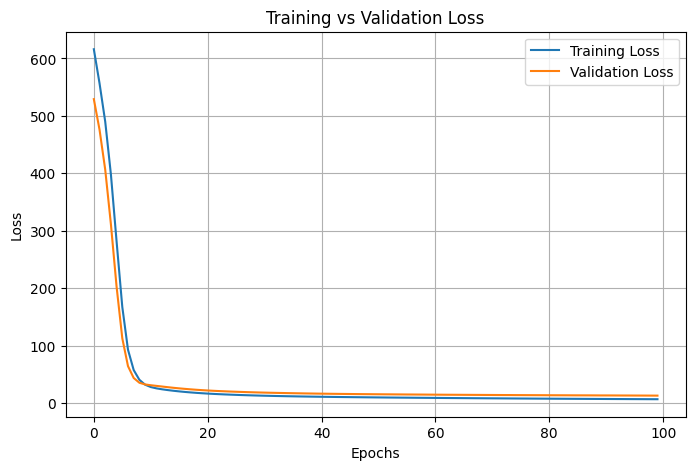

In [13]:
# -------------------------------
# 12. Plot training and validation loss
# -------------------------------
plt.figure(figsize=(8, 5))
plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training vs Validation Loss')
plt.xlabel('Epochs')
plt.ylabel('Loss')
plt.legend()
plt.grid(True)
plt.show()

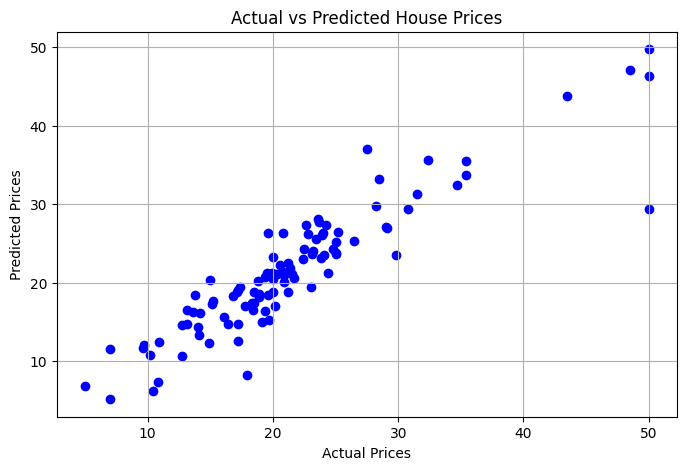

In [14]:
# -------------------------------
# 13. Plot actual vs predicted
# -------------------------------
plt.figure(figsize=(8, 5))
plt.scatter(y_test, y_pred, color='blue')
plt.xlabel("Actual Prices")
plt.ylabel("Predicted Prices")
plt.title("Actual vs Predicted House Prices")
plt.grid(True)
plt.show()